# Entrenamiento CNN-BiLSTM con validación cross-dataset

Variante de `01_Entrenamiento.ipynb` con **una sola configuración**: el modelo se entrena con cuatro datasets
(SisFall, KFall, UP-Fall y FallAllD, vía `set_b.parquet`) y se evalúa dos veces:

1. **Validación cruzada interna** sujeto-wise (`StratifiedGroupKFold`, 5 folds) sobre esos cuatro datasets.
2. **Holdout externo cross-dataset**: UMAFall (ausente del entrenamiento) se carga desde `set_a.parquet`
   y se evalúa con los modelos de fold y con el modelo final, en vista natural y balanceada.

Artefactos: `cross_final.keras`, `cross_scaler.joblib` y `cross_results.json` en `notebooks/data/modelos/falls/`.


## 1 · Imports y constantes


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import json
import pathlib
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

tf.keras.utils.set_random_seed(42)

FS = 50
WINDOW_SEC = 3.0
WINDOW_SIZE = int(FS * WINDOW_SEC)  # 150 timesteps
WINDOW_STEP = WINDOW_SIZE // 2      # 75 (50% overlap)
PEAK_MARGIN_SEC = 1.5
PEAK_MARGIN_SAMPLES = int(PEAK_MARGIN_SEC * FS)  # 75
N_FOLDS = 5

CHANNEL_COLS = ["AVM", "GVM"]
N_CHANNELS = len(CHANNEL_COLS)  # 2

# Subsampleo leve para acotar tiempo en CPU (15k/clase = 30k train — 7.5x el v1).
MAX_TRAIN_WINDOWS_PER_CLASS = 15000
MAX_TEST_WINDOWS_PER_CLASS = 5000
MAX_EPOCHS = 200
PATIENCE = 10
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

ORO_DIR = pathlib.Path("../data/oro/falls")
MODELS_DIR = pathlib.Path("../data/modelos/falls")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_NAME = "set_b"
EXTERNAL_DATASET = "UMAFall"          # holdout externo, ausente de set_b
CONFIG_PARQUET = ORO_DIR / "set_b.parquet"
EXTERNAL_PARQUET = ORO_DIR / "set_a.parquet"
CONFIGS = {CONFIG_NAME: CONFIG_PARQUET}

print(f"FS={FS} Hz | WINDOW_SIZE={WINDOW_SIZE} | PEAK_MARGIN={PEAK_MARGIN_SEC}s | N_FOLDS={N_FOLDS}")
print(f"Channels ({N_CHANNELS}): {CHANNEL_COLS}")
print(f"Config: {list(CONFIGS)} | holdout externo: {EXTERNAL_DATASET} | train/class={MAX_TRAIN_WINDOWS_PER_CLASS} | epochs={MAX_EPOCHS} | batch={BATCH_SIZE} | lr={LEARNING_RATE}")


FS=50 Hz | WINDOW_SIZE=150 | PEAK_MARGIN=1.5s | N_FOLDS=5
Channels (2): ['AVM', 'GVM']
Config: ['set_b'] | holdout externo: UMAFall | train/class=15000 | epochs=200 | batch=64 | lr=0.001


## 2 · Carga local de Parquet


In [2]:
def load_oro(path: pathlib.Path, filters=None) -> pd.DataFrame:
    df = pd.read_parquet(path, filters=filters)
    print(f"  Cargado: {path.name} → {df.shape[0]:,} filas, datasets: {sorted(df['Dataset'].unique())}")
    return df


## 3 · Mapeo a la taxonomía unificada

Diccionario `(Dataset, Activity_Code) → grupo_unificado` derivado de
`doc/taxonomía-unificada.md`. La taxonomía preserva las etiquetas originales de
cada dataset y los agrupa por mecanismo biomecánico (F1–F8) o por cobertura parcial
(F9 = solo dirección, F10 = solo mecanismo de impacto).

## Taxonomía Unificada de Caídas

|  ID  | Grupo                                            | Descripción                                                                       |
| :--: | ------------------------------------------------ | --------------------------------------------------------------------------------- |
| **F1**  | **Resbalón al caminar**                          | Caídas producidas por pérdida de fricción durante la marcha.                      |
| **F2**  | **Tropiezo al caminar**                          | Caídas ocasionadas por un obstáculo durante la marcha.                            |
| **F3**  | **Tropiezo al trotar**                           | Tropiezo ocurrido durante jogging o carrera ligera.                               |
| **F4**  | **Síncope caminando o de pie**                   | Caídas provocadas por pérdida de conciencia desde una postura erguida.            |
| **F5**  | **Caída al intentar sentarse**                   | Pérdida del equilibrio durante la transición de pie a sentado.                    |
| **F6**  | **Caída al intentar levantarse**                 | Caídas durante la transición de sentado a de pie.                                 |
| **F7**  | **Síncope estando sentado**                      | Caídas por pérdida de conciencia desde una posición sentada.                      |
| **F8**  | **Caída desde la cama**                          | Caídas producidas durante movimientos o cambios de posición sobre la cama.        |
| **F9**  | **Caídas clasificadas únicamente por dirección** | El dataset únicamente informa la dirección de la caída, sin especificar su causa. |
| **F10** | **Caídas clasificadas por mecanismo de impacto** | El dataset diferencia únicamente la forma de impacto durante la caída.            |

In [3]:
def build_taxonomy_map():
    """Mapeo (Dataset, Activity_Code) → grupo F1..F10.
    Fuentes: doc/taxonomía-unificada.md.
    Nota: A123–A126 de FallAllD son 'slipping' (no 'tripping'), por lo que
    caen en F1 (resbalón) junto con A103–A110.
    FallAllD en oro se almacena como int 101..135 (sin prefijo 'A'); KFall usa F01..F15."""
    m = {}
    for f, codes in {
        "F1": ["F01","F02","F03"], "F2": ["F04"], "F3": ["F05"], "F4": ["F06","F07"],
        "F5": ["F10","F11","F12"], "F6": ["F08","F09"], "F7": ["F13","F14","F15"],
    }.items():
        for c in codes: m[("SisFall", c)] = f
    for f, codes in {
        "F1": ["F13","F14","F15"], "F2": ["F11"], "F3": ["F12"], "F4": ["F09","F10"],
        "F5": ["F01","F02","F03"], "F6": ["F04","F05"], "F7": ["F06","F07","F08"],
    }.items():
        for c in codes: m[("KFall", c)] = f
    for f, codes in {
        "F1": ["103","104","105","106","107","108","109","110",
                "123","124","125","126"],
        "F2": ["101","102","121","122"],
        "F4": ["111","112","113","114","132","133","134","135"],
        "F5": ["115","116","117","118","119","120"],
        "F7": ["129","130","131"], "F8": ["127","128"],
    }.items():
        for c in codes: m[("FallAllD", c)] = f
    for f, codes in {"F5": ["5"], "F9": ["3","4"], "F10": ["1","2"]}.items():
        for c in codes: m[("UPFall", c)] = f
    for code in ["forwardFall", "backwardFall", "lateralFall"]:
        m[("UMAFall", code)] = "F9"
    return m

def map_to_unified_taxonomy(df):
    """Añade 'Fall_Type_Unified' preservando códigos originales.
    Asigna 'ADL' para actividades cotidianas y 'UNMAPPED' si el código de caída no está."""
    tax = build_taxonomy_map()
    out = df.copy()
    datasets = out["Dataset"].values
    codes = out["Activity_Code"].astype(str).values
    labels = out["Activity_Label"].values
    out["Fall_Type_Unified"] = [
        "ADL" if lbl == "ADL" else tax.get((ds, c), "UNMAPPED")
        for ds, c, lbl in zip(datasets, codes, labels)
    ]
    return out

TAXONOMY_ABBR = {
    "F1": "RC", "F2": "TC", "F3": "TT", "F4": "SC", "F5": "CS",
    "F6": "CL", "F7": "SS", "F8": "CC", "F9": "SD", "F10": "SM",
    "ADL": "ADL",
}
TAXONOMY_FULL = {
    "F1": "Resbalón caminando", "F2": "Tropiezo caminando",
    "F3": "Tropiezo trotando", "F4": "Síncope caminando/de pie",
    "F5": "Caída al intentar sentarse", "F6": "Caída al intentar levantarse",
    "F7": "Síncope estando sentado", "F8": "Caída desde la cama",
    "F9": "Solo dirección (UPFall/UMAFall)",
    "F10": "Solo mecanismo (UPFall)", "ADL": "Actividad de la Vida Diaria",
}


## 4 · Ventaneo precomputado

Se generan ventanas temporales de longitud fija a partir de las señales inerciales, utilizando un solapamiento del 50 %. Cada ventana se etiqueta como `ADL` o `Fall` según su contenido:

- Las ventanas de actividades cotidianas se etiquetan como `ADL`.
- En los trials de caída, se identifica el pico de `AVM`.
- Solo las ventanas cuyo centro se encuentra dentro de ±1.5 segundos del pico se etiquetan como `Fall`.
- Las ventanas restantes se conservan como `ADL`.

También se preparan las etiquetas de la taxonomía unificada y los identificadores de sujeto, que posteriormente se utilizan para la partición por grupos, el escalado y el entrenamiento del modelo.


In [4]:
def build_group_id(df):
    df = df.copy()
    df["Group_ID"] = df["Dataset"] + "_" + df["Subject"].astype(str)
    return df

def create_windows(df, window_size=WINDOW_SIZE, window_step=WINDOW_STEP,
                   channel_cols=CHANNEL_COLS, peak_margin_samples=PEAK_MARGIN_SAMPLES):
    """Vectorizado. Etiqueta Fall=1 sólo a ventanas centradas ±peak_margin del pico AVM.
    Ventanas en trials ADL son siempre 0. Ventanas en trials Fall fuera de la ventana
    del pico son también 0 (caminar pre/post impacto, reposo)."""
    X_chunks, y_chunks, ft_chunks, gid_chunks = [], [], [], []
    df = build_group_id(df)
    half_w = window_size // 2
    for keys, group in df.groupby(["Dataset", "Subject", "Activity_Code", "Trial"], sort=False):
        group = group.sort_values("Sample_Index").reset_index(drop=True)
        n = len(group)
        if n < window_size:
            continue
        data = group[channel_cols].values
        is_fall = group["Activity_Label"].iloc[0] == "Fall"
        ft = group["Fall_Type_Unified"].iloc[0] if "Fall_Type_Unified" in group.columns else "ADL"
        gid = group["Group_ID"].iloc[0]
        n_w = (n - window_size) // window_step + 1
        starts = np.arange(n_w) * window_step
        idx = starts[:, None] + np.arange(window_size)[None, :]
        X_chunks.append(data[idx])

        if is_fall:
            peak_idx = int(np.argmax(group["AVM"].values))
            centers = starts + half_w
            labels = (np.abs(centers - peak_idx) <= peak_margin_samples).astype(np.int32)
        else:
            labels = np.zeros(n_w, dtype=np.int32)
        y_chunks.append(labels)
        ft_chunks.append(np.full(n_w, ft, dtype=object))
        gid_chunks.append(np.full(n_w, gid, dtype=object))
    X = np.concatenate(X_chunks, axis=0).astype(np.float32)
    y = np.concatenate(y_chunks)
    ft = np.concatenate(ft_chunks)
    gid = np.concatenate(gid_chunks)
    print(f"  Ventanas precomputadas: {len(X):,} (Fall={int(y.sum()):,}, ADL={int((y==0).sum()):,}, ratio Fall={y.mean():.3f})")
    return X, y, ft, gid

def subsample(X, y, ft, gid, max_per_class, seed):
    """Subsampleo estratificado por clase."""
    rng = np.random.default_rng(seed)
    keep = []
    for cls in (0, 1):
        idx = np.where(y == cls)[0]
        if len(idx) > max_per_class:
            idx = rng.choice(idx, size=max_per_class, replace=False)
        keep.append(idx)
    keep = np.concatenate(keep)
    rng.shuffle(keep)
    return X[keep], y[keep], ft[keep], gid[keep]

def fit_scaler(X_train):
    n, t, c = X_train.shape
    s = StandardScaler()
    s.fit(X_train.reshape(-1, c))
    return s

def apply_scaler(X, s):
    n, t, c = X.shape
    return s.transform(X.reshape(-1, c)).reshape(n, t, c).astype(np.float32)


## 5 · Función de pérdida y arquitectura CNN-BiLSTM

En esta sección se define el modelo CNN-BiLSTM para la clasificación binaria de ventanas temporales como `ADL` o `Fall`.

La red combina capas `Conv1D` para extraer patrones locales de las señales inerciales, normalización por lotes, activaciones `ReLU` y operaciones de *max pooling* para reducir la dimensión temporal. Posteriormente, una capa `Bidirectional LSTM` modela las dependencias temporales en ambas direcciones. Finalmente, `Dropout` ayuda a reducir el sobreajuste y una capa densa con activación sigmoide produce la probabilidad de caída.

El modelo se entrena mediante `BinaryCrossentropy`, el optimizador Adam y una tasa de aprendizaje de `1e-3`. Durante el entrenamiento se utiliza `class_weight={0: 2.0, 1: 1.0}` para ponderar las clases según la distribución esperada de los datos.

In [5]:
def build_cnn_bilstm(window_size=WINDOW_SIZE, n_channels=N_CHANNELS):
    """Conv1D k=7 + k=5 + k=3 → campo receptivo 18 muestras (~0.36 s @ 50 Hz, salto j=4)."""
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(window_size, n_channels)),
        tf.keras.layers.Conv1D(32, kernel_size=7, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.Conv1D(64, kernel_size=5, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(64, kernel_size=3, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


## 6 · Métricas binarias

Se utilizan tres métricas para evaluar la clasificación de ventanas como `Fall` o `ADL`:

- **Sensibilidad (Recall):** proporción de caídas correctamente detectadas.
  
  $$
  \text{Sensibilidad} = \frac{TP}{TP + FN}
  $$

- **Especificidad:** proporción de actividades cotidianas correctamente identificadas.
  
  $$
  \text{Especificidad} = \frac{TN}{TN + FP}
  $$

- **Precisión (Precision):** proporción de predicciones de caída que son correctas.
  
  $$
  \text{Precisión} = \frac{TP}{TP + FP}
  $$

Donde `TP` son verdaderos positivos, `TN` verdaderos negativos, `FP` falsos positivos y `FN` falsos negativos.

In [6]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    return {
        "sensitivity": round(sens, 4),
        "specificity": round(spec, 4),
        "precision": round(prec, 4),
        "tp": tp, "fn": fn, "tn": tn, "fp": fp,
    }


## 7 · Orquestación del experimento

Se aplica validación cruzada estratificada por grupos mediante `StratifiedGroupKFold(K=5)` sobre `Group_ID`, con una partición interna del 10 % mediante `GroupShuffleSplit`. El `StandardScaler` se ajusta exclusivamente con los datos de entrenamiento de cada fold para evitar filtraciones.

El modelo se entrena con `BinaryCrossentropy`, `class_weight={0: 2.0, 1: 1.0}`, `EarlyStopping(patience=PATIENCE)` (=10) y `ReduceLROnPlateau`. Como salvaguarda contra *data mixing*, cada fold registra los datasets y las etiquetas presentes en el conjunto de entrenamiento.


In [7]:
def run_experiment(config_name, X, y, ft, gid, all_datasets, external=None):
    y_binary = y.astype(int)
    sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    folds = []
    ext_folds = []

    for fold_idx, (tr, te) in enumerate(sgkf.split(np.zeros(len(X)), y_binary, gid)):
        print(f"\n--- Fold {fold_idx + 1}/{N_FOLDS} ---")
        train_idx, test_idx = tr, te

        gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=fold_idx)
        it, iv = next(gss.split(
            np.zeros(len(train_idx)),
            y_binary[train_idx],
            gid[train_idx],
        ))
        inner_train = train_idx[it]
        val_idx = train_idx[iv]

        train_datasets = sorted({gid[i].split("_")[0] for i in inner_train})
        train_labels = sorted({("Fall" if y[i] == 1 else "ADL") for i in inner_train})
        missing_ds = sorted(set(all_datasets) - set(train_datasets))
        missing_lb = sorted({"Fall", "ADL"} - set(train_labels))
        if missing_ds:
            print(f"  \u26a0 Data mixing: train no contiene datasets: {missing_ds}")
        if missing_lb:
            print(f"  \u26a0 Data mixing: train no contiene etiquetas: {missing_lb}")
        print(f"  train datasets={train_datasets}  labels={train_labels}")

        Xtr, ytr, fttr, gtr = subsample(
            X[inner_train], y[inner_train], ft[inner_train], gid[inner_train],
            MAX_TRAIN_WINDOWS_PER_CLASS, seed=fold_idx,
        )
        Xva, yva, _, _ = subsample(
            X[val_idx], y[val_idx], ft[val_idx], gid[val_idx],
            max(500, MAX_TRAIN_WINDOWS_PER_CLASS // 15), seed=fold_idx + 100,
        )
        Xte, yte, ftte, _ = subsample(
            X[test_idx], y[test_idx], ft[test_idx], gid[test_idx],
            MAX_TEST_WINDOWS_PER_CLASS, seed=fold_idx + 200,
        )
        print(f"  Train: {len(Xtr):,} (Fall={int(ytr.sum()):,})  Val: {len(Xva):,}  Test: {len(Xte):,} (Fall={int(yte.sum()):,})")

        scaler = fit_scaler(Xtr)
        Xtr = apply_scaler(Xtr, scaler)
        Xva = apply_scaler(Xva, scaler)
        Xte = apply_scaler(Xte, scaler)

        model = build_cnn_bilstm()
        # Compensa subsampleo 50/50 hacia la distribucion natural (~10% Fall): ADL pesa 2x
        class_weight = {0: 2.0, 1: 1.0}
        model.fit(
            Xtr, ytr,
            validation_data=(Xva, yva),
            epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, verbose=0,
            class_weight=class_weight,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
                tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
            ],
        )

        y_pred = (model.predict(Xte, verbose=0).flatten() >= 0.5).astype(int)
        m = compute_metrics(yte, y_pred)
        folds.append({**m, "y_test": yte.tolist(), "y_pred": y_pred.tolist(),
                      "ft_test": ftte.tolist()})
        print(f"  Sens: {m['sensitivity']:.4f}  Spec: {m['specificity']:.4f}  Prec: {m['precision']:.4f}")

        # Holdout externo con el modelo y el scaler de este fold (antes de liberar el modelo).
        if external is not None:
            ext_name, X_ext, y_ext, ft_ext, gid_ext = external
            y_ext_pred = (model.predict(apply_scaler(X_ext, scaler), verbose=0).flatten() >= 0.5).astype(int)
            m_ext = compute_metrics(y_ext, y_ext_pred)

            n_ext_fall = max(int(y_ext.sum()), 1)
            Xb, yb, ftb, _ = subsample(X_ext, y_ext, ft_ext, gid_ext, n_ext_fall, seed=fold_idx + 300)
            yb_pred = (model.predict(apply_scaler(Xb, scaler), verbose=0).flatten() >= 0.5).astype(int)
            mb_ext = compute_metrics(yb, yb_pred)

            ext_folds.append({"fold": fold_idx, "natural": m_ext, "balanced": mb_ext,
                              "y_test": y_ext.tolist(), "y_pred": y_ext_pred.tolist(),
                              "ft_test": ft_ext.tolist()})
            print(f"  [{ext_name}] natural   Sens: {m_ext['sensitivity']:.4f}  Spec: {m_ext['specificity']:.4f}  Prec: {m_ext['precision']:.4f}")
            print(f"  [{ext_name}] balanceado Sens: {mb_ext['sensitivity']:.4f}  Spec: {mb_ext['specificity']:.4f}  Prec: {mb_ext['precision']:.4f}")

        del model, Xtr, Xva, Xte

        tf.keras.backend.clear_session()

    agg = {}
    for k in ("sensitivity", "specificity", "precision"):
        vals = [r[k] for r in folds]
        agg[f"{k}_mean"] = round(float(np.mean(vals)), 4)
        agg[f"{k}_std"] = round(float(np.std(vals)), 4)

    ext_summary = {"natural": {}, "balanced": {}}
    if ext_folds:
        for view in ("natural", "balanced"):
            for k in ("sensitivity", "specificity", "precision"):
                vals = [r[view][k] for r in ext_folds]
                ext_summary[view][f"{k}_mean"] = round(float(np.mean(vals)), 4)
                ext_summary[view][f"{k}_std"] = round(float(np.std(vals)), 4)

    return {"config": config_name, "folds": folds, "summary": agg,
            "external": {"name": external[0] if external else None,
                         "folds": ext_folds, "summary": ext_summary}}


## 8 · Ejecución de ambos experimentos

> En esta variante la configuración es única (`set_b`) y UMAFall se carga aparte como holdout externo (celda siguiente).


In [8]:
# Holdout externo: UMAFall solo existe en set_a.parquet; set_b nunca lo vio.
# pyarrow resuelve el filtro por Dataset en la lectura.
EXT_DF = load_oro(EXTERNAL_PARQUET, filters=[("Dataset", "==", EXTERNAL_DATASET)])
EXT_DF = map_to_unified_taxonomy(EXT_DF)

n_ext_subjects = EXT_DF[["Dataset", "Subject"]].drop_duplicates().shape[0]
print(f"  Sujetos {EXTERNAL_DATASET}: {n_ext_subjects}")

X_ext, y_ext, ft_ext, gid_ext = create_windows(EXT_DF)
del EXT_DF


  Cargado: set_a.parquet → 398,637 filas, datasets: ['UMAFall']
  Sujetos UMAFall: 18


  Ventanas precomputadas: 4,315 (Fall=324, ADL=3,991, ratio Fall=0.075)


In [9]:
results = {}
for config_name, parquet_path in CONFIGS.items():
    print(f"\n{'='*60}\nCONFIGURACIÓN: {config_name}\n{'='*60}")
    df = load_oro(parquet_path)
    df = map_to_unified_taxonomy(df)

    unmapped = int(((df["Activity_Label"] == "Fall") & (df["Fall_Type_Unified"] == "UNMAPPED")).sum())
    if unmapped > 0:
        rows = df[
            (df["Activity_Label"] == "Fall") & (df["Fall_Type_Unified"] == "UNMAPPED")
        ][["Dataset", "Activity_Code"]].drop_duplicates()
        print(f"  ⚠ {unmapped:,} filas de caída sin mapeo ({len(rows)} códigos):")
        print(rows.to_string(index=False))

    n_subjects = df[["Dataset", "Subject"]].drop_duplicates().shape[0]
    print(f"  Sujetos: {n_subjects}")

    X, y, ft, gid = create_windows(df)
    all_datasets = sorted(df["Dataset"].unique())
    results[config_name] = run_experiment(
            config_name, X, y, ft, gid, all_datasets,
            external=(EXTERNAL_DATASET, X_ext, y_ext, ft_ext, gid_ext),
        )
    del df, X, y, ft, gid



CONFIGURACIÓN: set_b


  Cargado: set_b.parquet → 8,442,379 filas, datasets: ['FallAllD', 'KFall', 'SisFall', 'UPFall']


  Sujetos: 101


  Ventanas precomputadas: 97,037 (Fall=9,332, ADL=87,705, ratio Fall=0.096)



--- Fold 1/5 ---
  train datasets=['FallAllD', 'KFall', 'SisFall', 'UPFall']  labels=['ADL', 'Fall']
  Train: 21,752 (Fall=6,752)  Val: 1,768  Test: 6,812 (Fall=1,812)


...

  Sens: 0.9778  Spec: 0.9942  Prec: 0.9845


  [UMAFall] natural   Sens: 0.9846  Spec: 0.9917  Prec: 0.9062
  [UMAFall] balanceado Sens: 0.9846  Spec: 0.9938  Prec: 0.9938



--- Fold 5/5 ---
  train datasets=['FallAllD', 'KFall', 'SisFall', 'UPFall']  labels=['ADL', 'Fall']
  Train: 21,882 (Fall=6,882)  Val: 1,555  Test: 6,895 (Fall=1,895)


  Sens: 0.9873  Spec: 0.9918  Prec: 0.9786


  [UMAFall] natural   Sens: 0.9877  Spec: 0.9895  Prec: 0.8840
  [UMAFall] balanceado Sens: 0.9877  Spec: 0.9815  Prec: 0.9816


## 9 · Tabla comparativa y persistencia

> Esta variante persiste los resultados en `cross_results.json` (CV interna + holdout externo natural/balanceado).


In [10]:
rows = []
for config_name, r in results.items():
    s = r["summary"]
    rows.append({
        "Config": config_name,
        "Sensibilidad": f"{s['sensitivity_mean']:.4f} \u00b1 {s['sensitivity_std']:.4f}",
        "Especificidad": f"{s['specificity_mean']:.4f} \u00b1 {s['specificity_std']:.4f}",
        "Precisi\u00f3n": f"{s['precision_mean']:.4f} \u00b1 {s['precision_std']:.4f}",
    })
print("Tabla Comparativa de Resultados (media \u00b1 desv\u00edo entre K folds)")
print("=" * 80)
print(pd.DataFrame(rows).set_index("Config").to_string())

for config_name, r in results.items():
    ext = r.get("external") or {}
    if ext.get("folds"):
        for view in ("natural", "balanced"):
            s = ext["summary"][view]
            print(f"{config_name} \u2192 {ext['name']} [{view}]: "
                  f"Sens {s['sensitivity_mean']:.4f} \u00b1 {s['sensitivity_std']:.4f}  "
                  f"Spec {s['specificity_mean']:.4f} \u00b1 {s['specificity_std']:.4f}  "
                  f"Prec {s['precision_mean']:.4f} \u00b1 {s['precision_std']:.4f}")

out_path = MODELS_DIR / "cross_results.json"
with open(out_path, "w") as f:
    json.dump(results, f, indent=2, default=str)
print(f"\n\u2713 Resultados persistidos en {out_path}")


Tabla Comparativa de Resultados (media ± desvío entre K folds)
           Sensibilidad    Especificidad        Precisión
Config                                                   
set_b   0.9765 ± 0.0110  0.9941 ± 0.0013  0.9842 ± 0.0032
set_b → UMAFall [natural]: Sens 0.9846 ± 0.0020  Spec 0.9917 ± 0.0012  Prec 0.9064 ± 0.0120
set_b → UMAFall [balanced]: Sens 0.9846 ± 0.0020  Spec 0.9920 ± 0.0054  Prec 0.9920 ± 0.0053

✓ Resultados persistidos en ..\data\modelos\falls\cross_results.json


In [11]:
import joblib

for config_name, parquet_path in CONFIGS.items():
    print(f"\nEntrenando modelo final para {config_name} (todo el set, subsampleo por presupuesto CPU)...")
    df = load_oro(parquet_path)
    df = map_to_unified_taxonomy(df)

    X, y, ft, gid = create_windows(df)
    Xtr, ytr, fttr, gtr = subsample(
        X, y, ft, gid, MAX_TRAIN_WINDOWS_PER_CLASS, seed=42,
    )

    gss = GroupShuffleSplit(n_splits=1, test_size=0.05, random_state=42)
    tr_idx, va_idx = next(gss.split(np.zeros(len(Xtr)), ytr, gtr))

    # Escalador ajustado solo con el split de entrenamiento (sin fuga hacia validacion).
    scaler = fit_scaler(Xtr[tr_idx])
    Xtr_s = apply_scaler(Xtr, scaler)

    model = build_cnn_bilstm()
    class_weight = {0: 2.0, 1: 1.0}
    model.fit(
        Xtr_s[tr_idx], ytr[tr_idx],
        validation_data=(Xtr_s[va_idx], ytr[va_idx]),
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, verbose=0,
        class_weight=class_weight,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
        ],
    )

    model_path = MODELS_DIR / "cross_final.keras"
    scaler_path = MODELS_DIR / "cross_scaler.joblib"
    model.save(model_path)
    joblib.dump(scaler, scaler_path)
    size_kb = model_path.stat().st_size / 1024
    print(f"  OK Modelo: {model_path}  ({size_kb:.1f} KB)")
    print(f"  OK Scaler: {scaler_path}")

    del df, X, y, Xtr, model

    tf.keras.backend.clear_session()



Entrenando modelo final para set_b (todo el set, subsampleo por presupuesto CPU)...


  Cargado: set_b.parquet → 8,442,379 filas, datasets: ['FallAllD', 'KFall', 'SisFall', 'UPFall']


  Ventanas precomputadas: 97,037 (Fall=9,332, ADL=87,705, ratio Fall=0.096)


  OK Modelo: ..\data\modelos\falls\cross_final.keras  (1125.7 KB)
  OK Scaler: ..\data\modelos\falls\cross_scaler.joblib


In [12]:
# Evaluacion del modelo final sobre el holdout externo UMAFall (natural + balanceado).
scaler_final = joblib.load(MODELS_DIR / "cross_scaler.joblib")
model_final = tf.keras.models.load_model(MODELS_DIR / "cross_final.keras")

y_ext_pred_final = (model_final.predict(apply_scaler(X_ext, scaler_final), verbose=0).flatten() >= 0.5).astype(int)
m_final_nat = compute_metrics(y_ext, y_ext_pred_final)

n_ext_fall = max(int(y_ext.sum()), 1)
Xb, yb, ftb, _ = subsample(X_ext, y_ext, ft_ext, gid_ext, n_ext_fall, seed=42)
yb_pred_final = (model_final.predict(apply_scaler(Xb, scaler_final), verbose=0).flatten() >= 0.5).astype(int)
m_final_bal = compute_metrics(yb, yb_pred_final)

print(f"{EXTERNAL_DATASET} - modelo final, natural ({len(y_ext):,} ventanas, Fall={n_ext_fall:,}, {n_ext_fall/len(y_ext):.1%}):")
print(f"  Sens: {m_final_nat['sensitivity']:.4f}  Spec: {m_final_nat['specificity']:.4f}  Prec: {m_final_nat['precision']:.4f}")
print(f"{EXTERNAL_DATASET} - modelo final, balanceado ({len(yb):,} ventanas, 50/50):")
print(f"  Sens: {m_final_bal['sensitivity']:.4f}  Spec: {m_final_bal['specificity']:.4f}  Prec: {m_final_bal['precision']:.4f}")

final_ext_record = {"y_test": y_ext.tolist(), "y_pred": y_ext_pred_final.tolist(), "ft_test": ft_ext.tolist()}

cross_path = MODELS_DIR / "cross_results.json"
with open(cross_path) as f:
    cross_results = json.load(f)
cross_results["external_final"] = {"name": EXTERNAL_DATASET, "natural": m_final_nat,
                                   "balanced": m_final_bal, **final_ext_record}
with open(cross_path, "w") as f:
    json.dump(cross_results, f, indent=2, default=str)
print(f"\nOK Resultados cross persistidos en {cross_path}")


UMAFall - modelo final, natural (4,315 ventanas, Fall=324, 7.5%):
  Sens: 0.9938  Spec: 0.9922  Prec: 0.9122
UMAFall - modelo final, balanceado (648 ventanas, 50/50):
  Sens: 0.9938  Spec: 0.9969  Prec: 0.9969

OK Resultados cross persistidos en ..\data\modelos\falls\cross_results.json


## 10 · Matriz de confusión 2×2

Para cada modelo se agrega la matriz de confusión de los K folds. Dentro de cada cuadrante
se reportan los **3 grupos de la taxonomía unificada con mayor volumen de muestras**
(porcentaje sobre el subtotal de esos 3 grupos, no sobre el total del cuadrante). Las etiquetas son abreviaturas de 2 letras;
la leyenda fuera del gráfico decodifica cada abreviatura.


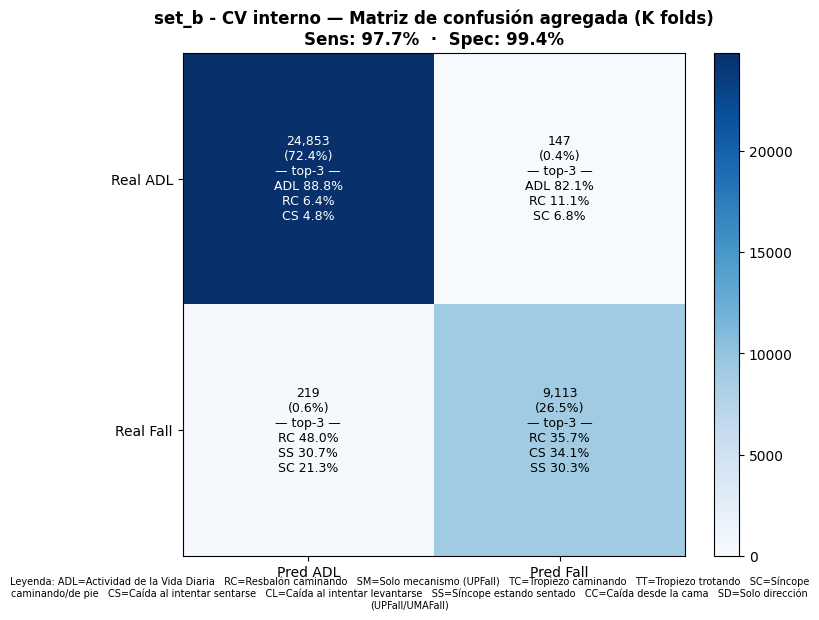

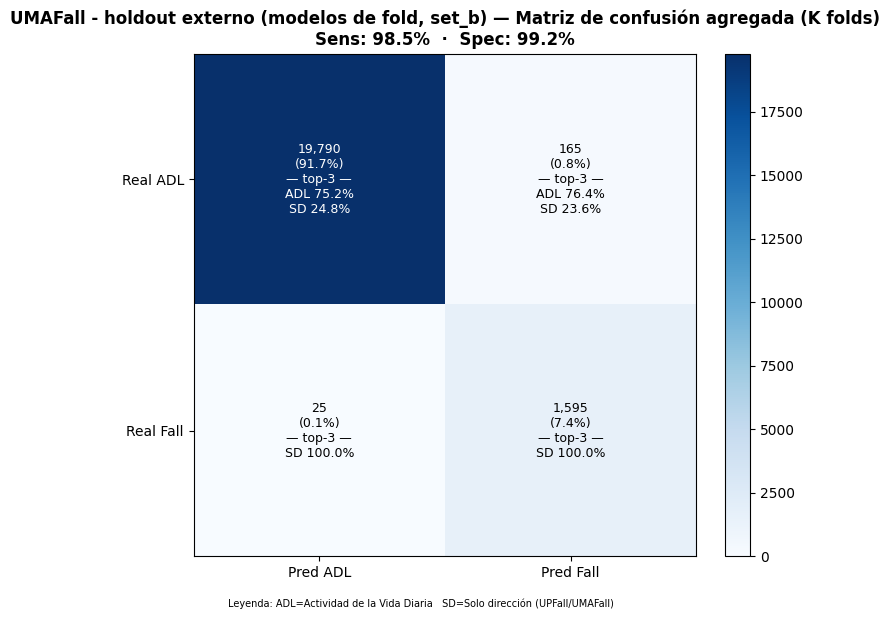

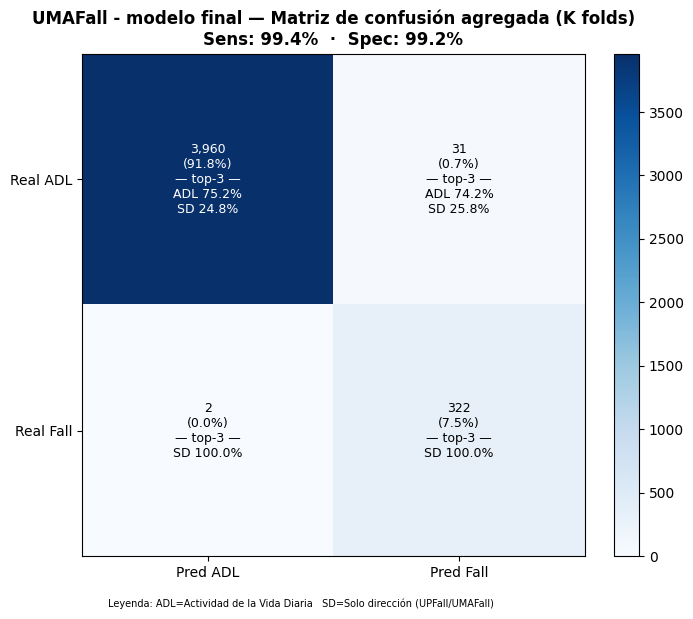

In [13]:
def top3_per_quadrant(y_test, y_pred, ft, quadrant_mask):
    if quadrant_mask.sum() == 0:
        return []
    groups = np.asarray(ft)[quadrant_mask]
    totals = pd.Series(groups).value_counts()
    top = totals.head(3)
    pct = (top / top.sum() * 100).round(1)
    return [(TAXONOMY_ABBR.get(g, g), f"{p:.1f}%") for g, p in pct.items()]

def plot_confusion_with_groups(config_name, fold_records):
    y_test = np.concatenate([np.asarray(f["y_test"]) for f in fold_records])
    y_pred = np.concatenate([np.asarray(f["y_pred"]) for f in fold_records])
    ft = np.concatenate([np.asarray(f["ft_test"]) for f in fold_records])

    tp = (y_test == 1) & (y_pred == 1)
    fn = (y_test == 1) & (y_pred == 0)
    tn = (y_test == 0) & (y_pred == 0)
    fp = (y_test == 0) & (y_pred == 1)

    quadrants = {"TP": tp, "FN": fn, "TN": tn, "FP": fp}
    quadrant_text = {}
    for name, mask in quadrants.items():
        items = top3_per_quadrant(y_test, y_pred, ft, mask)
        quadrant_text[name] = "\n".join(f"{a} {p}" for a, p in items) if items else "—"

    cm = np.array([[int(tn.sum()), int(fp.sum())], [int(fn.sum()), int(tp.sum())]])
    cm_pct = cm / max(cm.sum(), 1) * 100

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap="Blues", vmin=0)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred ADL", "Pred Fall"])
    ax.set_yticklabels(["Real ADL", "Real Fall"])

    cell_labels = {(0, 0): "TN", (0, 1): "FP", (1, 0): "FN", (1, 1): "TP"}
    for i in range(2):
        for j in range(2):
            quad = cell_labels[(i, j)]
            txt = f"{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)\n— top-3 —\n{quadrant_text[quad]}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9,
                    color="white" if cm[i,j] > cm.max()/2 else "black")

    sens = cm[1, 1] / (cm[1, 1] + cm[1, 0]) if (cm[1, 1] + cm[1, 0]) > 0 else 0
    spec = cm[0, 0] / (cm[0, 0] + cm[0, 1]) if (cm[0, 0] + cm[0, 1]) > 0 else 0
    ax.set_title(f"{config_name} — Matriz de confusión agregada (K folds)\n"
                 f"Sens: {sens:.1%}  ·  Spec: {spec:.1%}", fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)

    used = sorted({g for f in fold_records for g in np.asarray(f["ft_test"])})
    legend = "   ".join(f"{TAXONOMY_ABBR.get(g, g)}={TAXONOMY_FULL.get(g, g)}" for g in used)
    fig.text(0.5, -0.02, "Leyenda: " + legend, ha="center", fontsize=7, wrap=True)
    plt.tight_layout()
    return fig

for config_name, r in results.items():
    fig = plot_confusion_with_groups(f"{config_name} - CV interno", r["folds"])
    plt.show()

    ext = r.get("external") or {}
    if ext.get("folds"):
        fig = plot_confusion_with_groups(
            f"{ext['name']} - holdout externo (modelos de fold, {config_name})",
            ext["folds"],
        )
        plt.show()

if "final_ext_record" in globals():
    fig = plot_confusion_with_groups(f"{EXTERNAL_DATASET} - modelo final", [final_ext_record])
    plt.show()


## 11 · Conclusión

Un único modelo (`set_b`: SisFall + KFall + UPFall + FallAllD) se evaluó en validación cruzada
sujeto-wise estratificada (5 folds) y en un holdout externo nunca visto: UMAFall
(capa oro de `set_a.parquet`, resampleado 20→50 Hz).

- CV interna `set_b`: Sens 0.9765 ± 0.0110, Spec 0.9941 ± 0.0013, Prec 0.9842 ± 0.0032.
- UMAFall con modelos de fold — natural: Sens 0.9846 ± 0.0020, Spec 0.9917 ± 0.0012, Prec 0.9064 ± 0.0120;
  balanceado 50/50: Sens 0.9846 ± 0.0020, Spec 0.9920 ± 0.0054, Prec 0.9920 ± 0.0053.
- UMAFall con modelo final — natural: Sens 0.9938, Spec 0.9922, Prec 0.9122 (322/324 caídas);
  balanceado 50/50: Sens 0.9938, Spec 0.9969, Prec 0.9969.

La brecha entre ambos niveles cuantifica el costo de generalizar a un dominio no visto (sensor,
tasa y resampleo distintos). Los artefactos quedaron en `notebooks/data/modelos/falls/`:
`cross_final.keras`, `cross_scaler.joblib` y `cross_results.json`.
